In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import matplotlib.dates as mdates

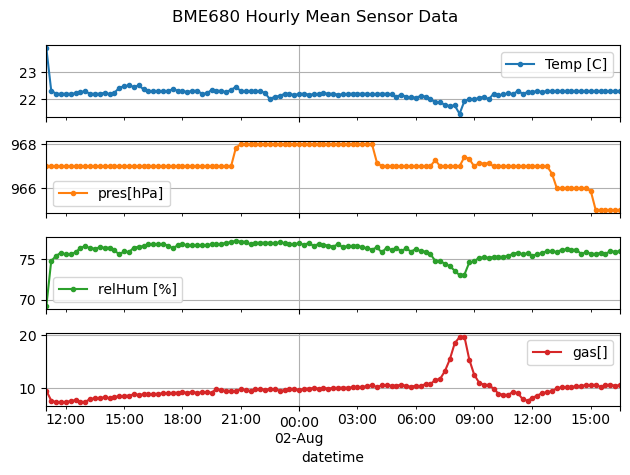

In [75]:
fnames = [
    'sensor_data_2026-08-01_11_12_05.csv',
    'sensor_data_2026-08-01_12_49_16.csv',
    'sensor_data_2026-08-01_13_07_13.csv'
]

dfs = {}

for fname in fnames:
    csv_path = Path(f'../data/{fname}').resolve()
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.set_index('datetime')
    dfs[fname] = df

plot_df = pd.concat(
    [df.assign(source_file=fname) for fname, df in dfs.items()]
).sort_index()

# Filter pressure values below 100 hPa to NaN before averaging.
plot_df.loc[plot_df['pres[hPa]'] < 100, 'pres[hPa]'] = np.nan


plot_cols = ['Temp [C]', 'pres[hPa]', 'relHum [%]', 'gas[]']
hourly_df = plot_df[plot_cols].resample('15min').mean()

axes = hourly_df.plot(
    y=plot_cols,
    subplots=True,
    layout=(4, 1),
    # figsize=(12, 8),
    grid=True,
    marker='.',
    title='BME680 Hourly Mean Sensor Data'
)

# start_time = pd.Timestamp('2026-08-01 11:00')
# locator = mdates.HourLocator(byhour=[12, 15, 18, 21, 0, 3, 6, 9])
# formatter = mdates.DateFormatter('%Y-%m-%d %H:%M')

# for ax in np.ravel(axes):
#     ax.set_xlim(left=start_time)
#     ax.xaxis.set_major_locator(locator)
#     ax.xaxis.set_major_formatter(formatter)
#     ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()